# 💰 定投策略回测

## 本节目标

用真实历史数据验证：
1. 定投 vs 一次性投资，谁更赚？
2. 不同定投频率有什么区别？
3. 加入止盈规则会怎样？
4. 网格交易 vs 定投
5. 构建你自己的定投计划

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

from scripts.data.client import get_fund_nav
from scripts.strategy.backtest import (
    backtest_dca, backtest_lump, backtest_grid, compare_strategies,
)
from scripts.utils import viz

print("✅ 回测引擎就绪")

✅ 回测引擎就绪


## 1. 定投 vs 一次性投资 — 世纪对决

假设你有一笔钱，是一次性全投进去，还是分批定投？
历史数据会给出答案。

In [3]:
# 对标沪深300指数基金，对比三种方式
compare_strategies(
    fund_code="110020",       # 易方达沪深300联接
    amount=100000,             # 一次性对比金额: 10万
    monthly_amount=5000,       # 每月定投: 5000
)

print("\n💡 定投不一定是收益最高的，但通常是风险调整后最好的。")
print("   尤其在市场先跌后涨时，定投的「微笑曲线」效应最明显。")


  策略回测对比 — 基金 110020
  数据范围: 2025-05-06 ~ 2026-05-06

  策略                          总投入         最终资产      总收益       年化     最大回撤     夏普
  ----------------------------------------------------------------------------
  一次性投资                   100,000      129,892    29.9%    29.9%    -7.2%   2.05
  定投(monthly)              60,000       67,007    11.7%    11.7%    -5.8%   0.08
  定投(weekly)               63,750       71,025    11.4%    11.4%    -4.9%   0.07

  [TIP] 分析:
  总收益最高: 一次性投资 (29.9%)
  风险调整后最佳: 一次性投资 (夏普 2.05)

💡 定投不一定是收益最高的，但通常是风险调整后最好的。
   尤其在市场先跌后涨时，定投的「微笑曲线」效应最明显。


## 2. 换个基金试试

不同基金定投效果不一样。试试行业基金 vs 宽基指数。

In [5]:
# 测试不同基金
TEST_CODES = {
    "110020": "沪深300联接",
    "001632": "中证500",
    "161725": "白酒行业",
}

for code, name in TEST_CODES.items():
    print(f"\n{'='*60}")
    print(f"  {name} ({code})")
    print(f"{'='*60}")
    try:
        nav = get_fund_nav(code)
        
        # 三种策略对比
        r_lump = backtest_lump(nav, 100000)
        r_dca_m = backtest_dca(nav, 5000, "monthly")
        r_dca_w = backtest_dca(nav, 1250, "weekly")
        
        for r in [r_lump, r_dca_m, r_dca_w]:
            print(f"  {r.strategy:<16} 总投入: {r.total_invested:>10,.0f}  "
                  f"最终资产: {r.final_value:>10,.0f}  "
                  f"总收益: {r.total_return:>7.1f}%  "
                  f"年化: {r.annual_return:>7.1f}%  "
                  f"最大回撤: {r.max_drawdown:>7.1f}%")
    except Exception as e:
        print(f"  ❌ {e}")


  沪深300联接 (110020)
  一次性投资            总投入:    100,000  最终资产:    129,892  总收益:    29.9%  年化:    29.9%  最大回撤:    -7.2%
  定投(monthly)      总投入:     60,000  最终资产:     67,007  总收益:    11.7%  年化:    11.7%  最大回撤:    -5.8%
  定投(weekly)       总投入:     63,750  最终资产:     71,025  总收益:    11.4%  年化:    11.4%  最大回撤:    -4.9%

  中证500 (001632)
  一次性投资            总投入:    100,000  最终资产:     90,698  总收益:    -9.3%  年化:    -9.3%  最大回撤:   -17.1%
  定投(monthly)      总投入:     60,000  最终资产:     55,648  总收益:    -7.2%  年化:    -7.2%  最大回撤:    -7.3%
  定投(weekly)       总投入:     63,750  最终资产:     59,380  总收益:    -6.8%  年化:    -6.8%  最大回撤:    -6.4%

  白酒行业 (161725)
  一次性投资            总投入:    100,000  最终资产:     77,924  总收益:   -22.1%  年化:   -22.1%  最大回撤:   -26.6%
  定投(monthly)      总投入:     60,000  最终资产:     50,110  总收益:   -16.5%  年化:   -16.5%  最大回撤:   -10.2%
  定投(weekly)       总投入:     63,750  最终资产:     53,598  总收益:   -15.9%  年化:   -15.9%  最大回撤:    -6.2%


## 3. 定投「微笑曲线」可视化

模拟一段先跌后涨的市场，看看定投如何在下跌中积累便宜份额，在反弹中获利。

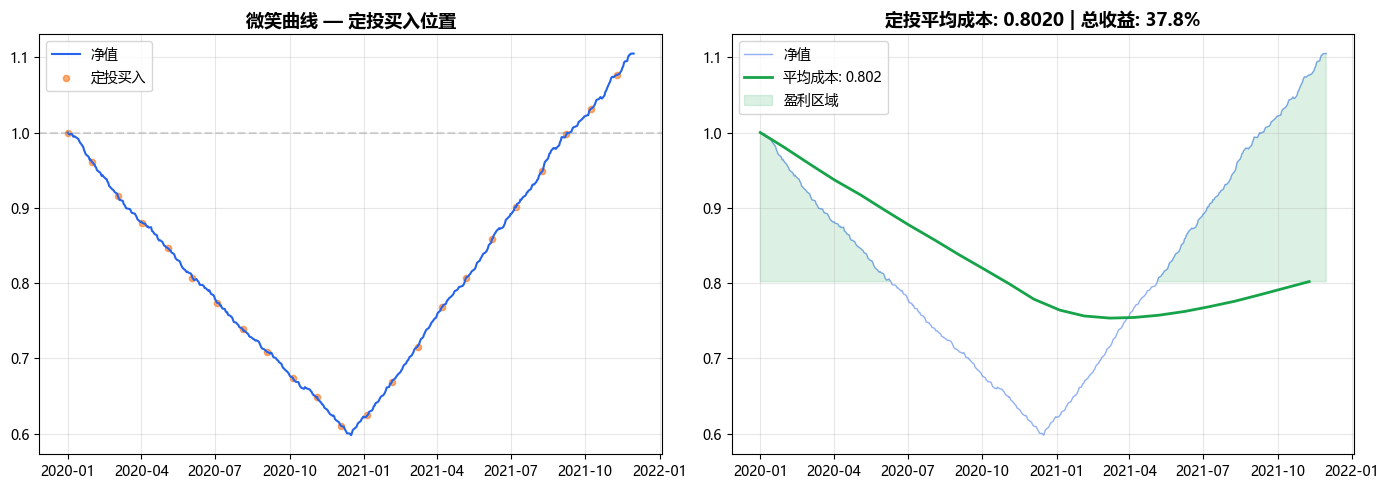


📊 微笑曲线回测结果:
  净值从 1.00 → 0.60 → 1.10
  总投入: 23,000 元
  最终资产: 31,686 元
  总收益率: 37.8%
  平均成本: 0.8020

💡 一次性投资在1.0买入，到1.1赚10%
   定投在下跌中买入更便宜份额，到1.1赚得更多！


In [6]:
# 模拟一段先跌后涨的行情
np.random.seed(42)
days = 500

# 前半段下跌，后半段上涨
trend = np.concatenate([
    np.linspace(1.0, 0.6, days//2),   # 跌40%
    np.linspace(0.6, 1.1, days//2),   # 涨回并创新高
])
noise = np.random.normal(0, 0.015, days)
nav = np.exp(np.log(trend) + noise.cumsum() * 0.1)
nav = nav / nav[0]

dates = pd.date_range("2020-01-01", periods=days, freq="B")
sim_df = pd.DataFrame({"date": dates, "nav": nav})
sim_df["daily_return"] = sim_df["nav"].pct_change()

# 定投模拟
n_months = days // 22
invest_amount = 1000
total_invested = 0
total_shares = 0
costs = []

for i in range(0, days, 22):
    price = sim_df["nav"].iloc[i]
    shares = invest_amount / price
    total_shares += shares
    total_invested += invest_amount
    avg_cost = total_invested / total_shares if total_shares > 0 else price
    costs.append(avg_cost)

final_value = total_shares * sim_df["nav"].iloc[-1]
total_return = (final_value - total_invested) / total_invested * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(sim_df["date"], sim_df["nav"], color="#2563EB", linewidth=1.5, label="净值")
invest_dates = sim_df["date"].iloc[::22]
invest_prices = sim_df["nav"].iloc[::22]
ax1.scatter(invest_dates, invest_prices, color="#F97316", s=20, alpha=0.6, label="定投买入")
ax1.axhline(1.0, color="gray", linestyle="--", alpha=0.3)
ax1.set_title("微笑曲线 — 定投买入位置", fontsize=13, fontweight="bold")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(sim_df["date"], sim_df["nav"], color="#2563EB", alpha=0.5, linewidth=1, label="净值")
ax2.plot(invest_dates, costs, color="#16A34A", linewidth=2, label=f"平均成本: {costs[-1]:.3f}")
ax2.fill_between(sim_df["date"], sim_df["nav"], costs[-1],
                  where=(sim_df["nav"] > costs[-1]),
                  alpha=0.15, color="#16A34A", label="盈利区域")
ax2.set_title(f"定投平均成本: {costs[-1]:.4f} | 总收益: {total_return:.1f}%",
              fontsize=13, fontweight="bold")
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

print(f"\n📊 微笑曲线回测结果:")
print(f"  净值从 1.00 → 0.60 → 1.10")
print(f"  总投入: {total_invested:,.0f} 元")
print(f"  最终资产: {final_value:,.0f} 元")
print(f"  总收益率: {total_return:.1f}%")
print(f"  平均成本: {costs[-1]:.4f}")
print(f"\n💡 一次性投资在1.0买入，到1.1赚10%")
print(f"   定投在下跌中买入更便宜份额，到1.1赚得更多！")

## 4. 智能定投 vs 普通定投

根据 PE 估值调整定投金额：便宜时多买，贵时少买。

In [7]:
# 模拟估值引导的智能定投
# 假设 PE 历史分位在 10%~90% 之间波动
np.random.seed(123)
days_sim = 1000

# 生成模拟净值（带趋势的随机游走）
returns_sim = np.random.normal(0.0003, 0.015, days_sim)
nav_sim = 1.0 * np.exp(returns_sim.cumsum())

# 生成模拟的 PE 分位数（均值回归过程）
pe_percentile = np.zeros(days_sim)
pe_percentile[0] = 50
for i in range(1, days_sim):
    pe_percentile[i] = pe_percentile[i-1] + np.random.normal(-0.02*(pe_percentile[i-1]-50), 2)
    pe_percentile[i] = np.clip(pe_percentile[i], 5, 95)

# 普通定投
normal_shares = 0
normal_invested = 0
normal_values = []

# 智能定投
smart_shares = 0
smart_invested = 0
smart_values = []

base_amount = 1000

for i in range(0, days_sim, 22):  # 每月
    price = nav_sim[i]
    pct = pe_percentile[i]
    
    # 普通: 固定金额
    normal_shares += base_amount / price
    normal_invested += base_amount
    
    # 智能: 根据估值调整
    if pct < 30:
        multiplier = 1.5
    elif pct > 70:
        multiplier = 0.5
    else:
        multiplier = 1.0
    smart_amount = base_amount * multiplier
    smart_shares += smart_amount / price
    smart_invested += smart_amount
    
    normal_values.append(normal_shares * price)
    smart_values.append(smart_shares * price)

normal_final = normal_shares * nav_sim[-1]
smart_final = smart_shares * nav_sim[-1]
normal_ret = (normal_final - normal_invested) / normal_invested * 100
smart_ret = (smart_final - smart_invested) / smart_invested * 100

print(f"\n📊 普通定投 vs 智能定投 (模拟 A 股 4 年数据):")
print(f"{'':<16} {'总投入':>10} {'最终资产':>12} {'总收益':>8}")
print(f"  {'普通定投':<14} {normal_invested:>10,.0f} {normal_final:>12,.0f} {normal_ret:>7.1f}%")
print(f"  {'智能定投':<14} {smart_invested:>10,.0f} {smart_final:>12,.0f} {smart_ret:>7.1f}%")
print(f"\n💡 智能定投在低估时多买、高估时少买，长期有望提升收益")


📊 普通定投 vs 智能定投 (模拟 A 股 4 年数据):
                        总投入         最终资产      总收益
  普通定投               46,000       35,196   -23.5%
  智能定投               46,500       35,373   -23.9%

💡 智能定投在低估时多买、高估时少买，长期有望提升收益


## 5. 投资组合优化

不把鸡蛋放在一个篮子里。用数学方法找到最优的资产配比。

In [8]:
from scripts.strategy.portfolio import optimize_portfolio

# 👇 改成你关注的基金
PORTFOLIO_CODES = ["110020", "001632", "050027"]

try:
    result = optimize_portfolio(PORTFOLIO_CODES)
    
    print("\n📊 组合优化结果:\n")
    for strategy, data in result["results"].items():
        print(f"  [{strategy}]")
        print(f"    预期年化: {data['return']*100:.1f}%")
        print(f"    预期波动: {data['volatility']*100:.1f}%")
        print(f"    夏普比率: {data['sharpe']:.2f}")
        weights_str = ", ".join(
            f"{c}: {w*100:.0f}%"
            for c, w in zip(PORTFOLIO_CODES, data["weights"])
        )
        print(f"    建议权重: {weights_str}")
        print()
except Exception as e:
    print(f"❌ {e}")

print("⚠️ 优化基于历史数据。市场结构会变化，权重需要定期调整。")


📊 组合优化结果:

  [最大夏普]
    预期年化: 13.7%
    预期波动: 7.1%
    夏普比率: 1.65
    建议权重: 110020: 50%, 001632: 5%, 050027: 45%

  [最小方差]
    预期年化: 0.0%
    预期波动: 6.0%
    夏普比率: -0.33
    建议权重: 110020: 29%, 001632: 21%, 050027: 50%

  [风险平价]
    预期年化: 0.0%
    预期波动: 2.2%
    夏普比率: -0.91
    建议权重: 110020: 8%, 001632: 7%, 050027: 85%

⚠️ 优化基于历史数据。市场结构会变化，权重需要定期调整。


## 6. 市场择时信号

看看当前市场给的信号是什么。

In [ ]:
from scripts.strategy.signals import composite_signal

# 综合 PE估值 + 均线 + RSI 信号
signal = composite_signal(fund_code="110020", index_code="000300")

print(f"📡 综合信号: {signal['overall_signal']}")
print(f"💡 建议: {signal['suggestion']}")

for name, s in signal["signals"].items():
    emoji = {"BUY": "🟢", "SELL": "🔴", "HOLD": "🟡", "WAIT": "⚪"}.get(
        s.get("signal", "?"), "❓"
    )
    print(f"\n{emoji} [{name}]: {s.get('signal', 'N/A')}")
    for k, v in s.items():
        if k != "signal":
            print(f"   {k}: {v}")

print(f"\n\n⚠️ 信号仅供参考，不构成投资建议。")
print(f"   机械执行定投纪律 > 根据信号频繁操作")

## 7. 制定你的定投计划

填写下面的模板，生成你自己的投资计划。

In [ ]:
# 👇 下面是你自己的投资计划模板

MY_PLAN = {
    "目标": "30年后退休补充养老金，目标 200 万",
    "每月投入": 3000,  # 元
    "基金选择": {
        "110020": {"名称": "沪深300联接", "比例": 50, "理由": "A股核心资产"},
        "001632": {"名称": "中证500", "比例": 30, "理由": "中盘成长"},
        "050027": {"名称": "纯债基金", "比例": 20, "理由": "降低波动"},
    },
    "定投频率": "每月15号",
    "止盈规则": "年化收益 > 20% 时赎回盈利部分",
    "再平衡": "每年12月调整一次恢复目标比例",
    "不做什么": [
        "不因为下跌而停止定投",
        "不追热点基金",
        "不频繁交易",
        "不用急用的钱投资",
    ],
}

# 计算预期
monthly = MY_PLAN["每月投入"]
years = 30
rate = 0.08  # 年化 8%

total_invested = monthly * 12 * years
final_value = monthly * ((1 + rate/12)**(12*years) - 1) / (rate/12) * (1 + rate/12)

print("📋 你的投资计划:")
print(f"  目标: {MY_PLAN['目标']}")
print(f"  每月投入: {monthly} 元")
print(f"  投资期限: {years} 年")
print(f"  预期年化: {rate*100:.0f}%")
print(f"  总投入: {total_invested:,.0f} 元")
print(f"  预期最终: {final_value:,.0f} 元")
print(f"  预期收益: {final_value - total_invested:,.0f} 元")
print()
print("📊 基金配置:")
for code, info in MY_PLAN["基金选择"].items():
    print(f"  {info['名称']} ({code}): {info['比例']}% — {info['理由']}")
print()
print("🚫 纪律:")
for rule in MY_PLAN["不做什么"]:
    print(f"  ❌ {rule}")

## 📝 本节小结

你已经学会：
- ✅ 回测定投 vs 一次性投资
- ✅ 理解微笑曲线为什么有效
- ✅ 智能定投（根据估值调整金额）
- ✅ 用数学方法优化投资组合
- ✅ 查看市场择时信号
- ✅ 制定自己的定投计划

### 新手的黄金法则

1. **宽基指数 + 长期定投** = 最高概率赚钱的组合
2. 不要试图预测市场，坚持定投纪律
3. 低估多买、高估少买，但不空仓
4. 至少持有 3 年以上，给复利时间
5. 投资之外，好好工作增加收入才是王道

### 后续学习
- 📖 阅读 `knowledge/04-分析方法/` 学基本面和技术分析
- 📖 阅读 `knowledge/05-投资策略/` 学高级策略
- 📖 阅读 `knowledge/06-风险管理/` 学如何控制风险

> ⚠️ 免责声明：本项目中所有内容仅供学习参考，不构成投资建议。投资有风险，决策需谨慎。